# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==2.2.2 scikit-learn==1.3.1 matplotlib==3.8.0 seaborn==0.13.1 xgboost==2.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.3
    Uninstalling xgboost-2.1.3:
      Successfully uninstalled xgboost-2.1.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.0
    Uninstalling scikit-learn-1.6.0:
      Successfully uninstalled scikit-learn-1.6.0
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.13.2
    Uninstalling seaborn-0.13.2:
      Successfully uninstalled seaborn-0.13.2


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Libraries to split data, impute missing values
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Libraries to import decision tree classifier and different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier

# Libtune to tune model, get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

### Reading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
visa = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EasyVisa.csv')

In [ ]:
# copying data to another varaible to avoid any changes to original data
data = visa.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# displaying the first and last 5 rows of the dataset
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
# understanding the shape of the dataset.
data.shape

(25480, 12)

In [ ]:
# checking data types and number of non-null values for each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- We can see that there are total of 12 columns and 25,480 rows in the dataset.
- The data types of the columns are integer (2), float (1), and object (9) type. Object type columns need to be converted to ordinal type.
- The number of non-null values of each column is equal to the number of total rows in the dataset i.e. no null value. We can further confirm this using `isna()` method.

In [ ]:
data.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


- There are no missing values in the data.

Let's convert the columns with an 'object' datatype into categorical variables.

In [ ]:
for feature in data.columns: # Loop through all columns in the dataframe
    if data[feature].dtype == 'object': # Only apply for columns with categorical strings
        data[feature] = pd.Categorical(data[feature])# Replace strings with an integer
data.head(10)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.3900,Year,Y,Certified
7,EZYV08,North America,Bachelor's,Y,N,3035,1924,West,418.2298,Hour,Y,Denied
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.1900,Year,Y,Certified
9,EZYV10,Europe,Doctorate,Y,N,2251,1995,South,67514.7600,Year,Y,Certified


### Summary of the dataset

In [ ]:
# getting the summary of the dataset.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


- The min for no_of_employees is -26, which seems to be odd as we expect this value to be a positive number.
- There is a huge gap between 75% and max for no_of_employees, which indicates a distribution of disproportionately large values.

### Number of unique values in each column

In [ ]:
data.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


- We can drop 'case_id' column as it is an ID variable and will not add value to the model.

In [ ]:
# dropping one column from the dataframe
data.drop(columns=['case_id'], inplace=True)

### Number of observations in each category

In [ ]:
cat_cols=['continent','education_of_employee','has_job_experience','requires_job_training','region_of_employment','unit_of_wage','full_time_position','case_status']

for column in cat_cols:
    print(data[column].value_counts())
    print('-'*30)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
------------------------------
full_time_position
Y    22773
N     2707
Name: count, dtype: int64
------------------------------
case_status
Certified    17018
Denied

- Asia has more applicants than any other continents.
- Most applicants do not require job training.
- Most applicants are seeking full time position that pays yearly.
- About 1/3 of the applicants are denied.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

### Univariate analysis

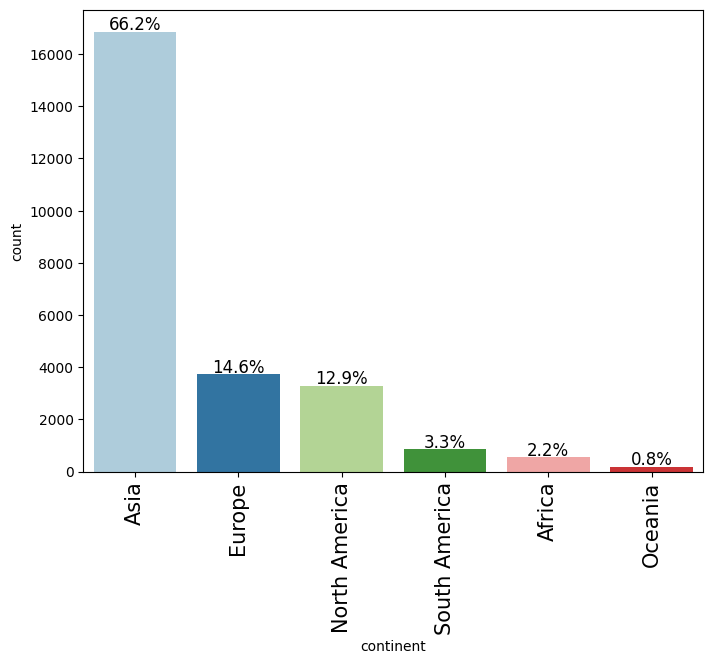

In [ ]:
# creating observations for continent
labeled_barplot(data, 'continent',perc=True)

- Asia has the highest percentage of observations i.e. 66.2%
- Europe and North America have 14.6% and 12.9% observations, respectively

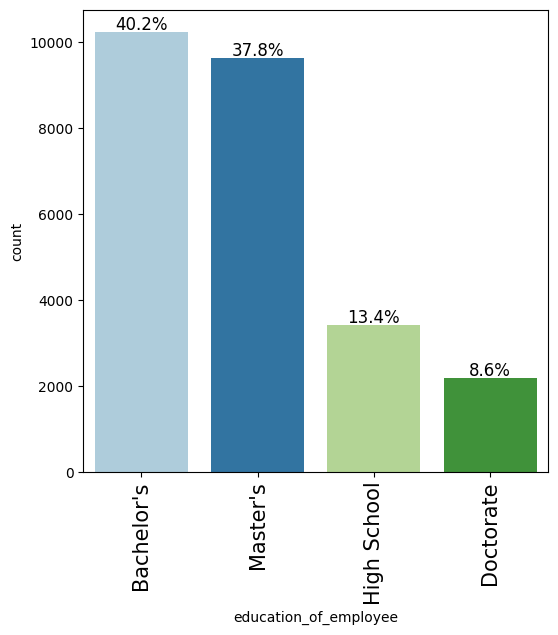

In [ ]:
# creating observations for education of employee
labeled_barplot(data, 'education_of_employee',perc=True)

- Bachelor's has the highest percentage of observations at 40.2%, followed by Master's at 37.8%.

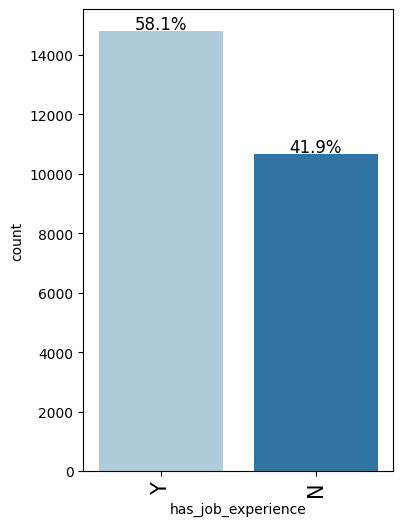

In [ ]:
# visualizing distribution of whether an applicant has job experience
labeled_barplot(data, 'has_job_experience',perc=True)

- 58.1% of the applicants have job experience.

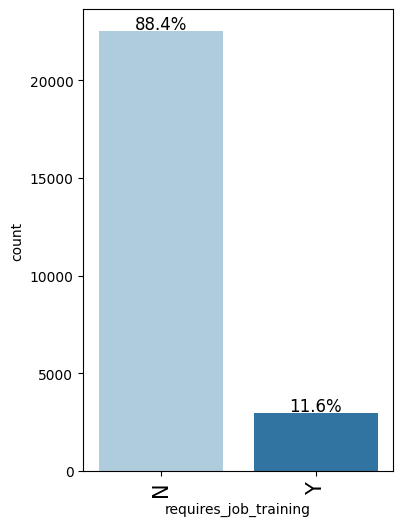

In [ ]:
# visualizing distribution of whether an applicant requires job training
labeled_barplot(data, 'requires_job_training',perc=True)

- 88.4% of the applicants do not require job training.

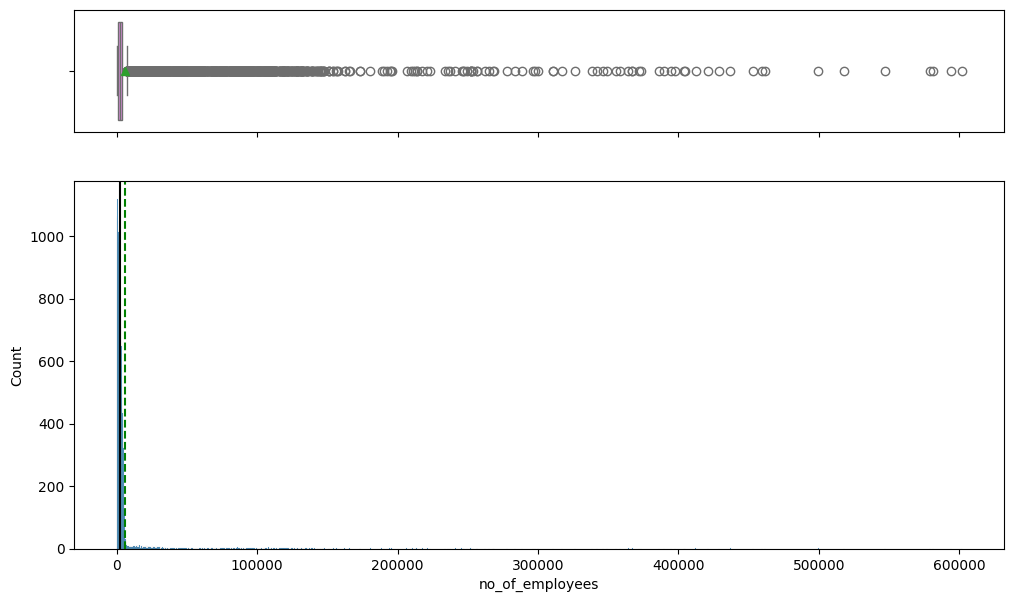

In [ ]:
# visualizing the distribution of number of employees
histogram_boxplot(data, 'no_of_employees')

- The distribution for the no_of_employees is right skewed and highly concentrated around the median.
- There are outliers above the maximum value.
- In order to better understand the distribution of no_of_employees, we will split the values into multiple groups.

In [ ]:
# categorizing no_of_employees into different sizes of companies
data['co_size'] = pd.cut(data['no_of_employees'],
                        bins=[-float('inf'), 1500, 2000, 5000, float('inf')],
                        labels=['Small', 'Medium', 'Large', 'Very large'],
                        right=False) # include lower bound, exclude upper bound in each bin

data.co_size.value_counts()

,count
co_size,
Large,10692
Small,9214
Medium,2934
Very large,2640


In [ ]:
# removing no_of_employees column from dataframe
data.drop(columns=['no_of_employees'], inplace=True)

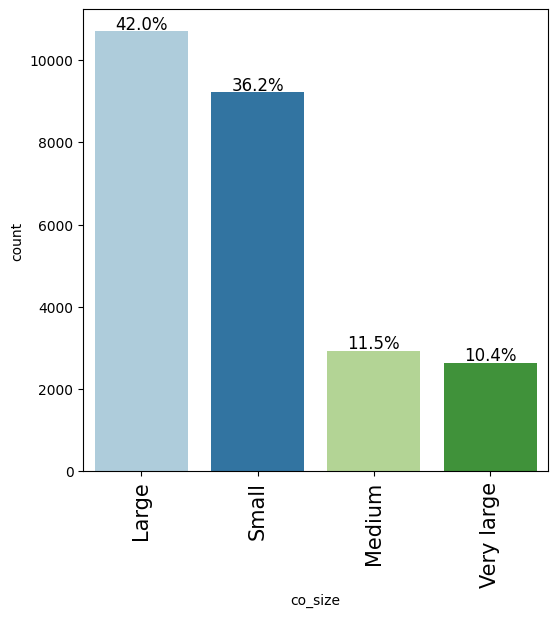

In [ ]:
# visualizing the distribution of co_size
labeled_barplot(data, 'co_size',perc=True)

* Large companies (with number of employees between 2000 and 5000) have the highest percentage of co_size at 42.0%, followed by small companies (with employees <1500) at 36.2%.

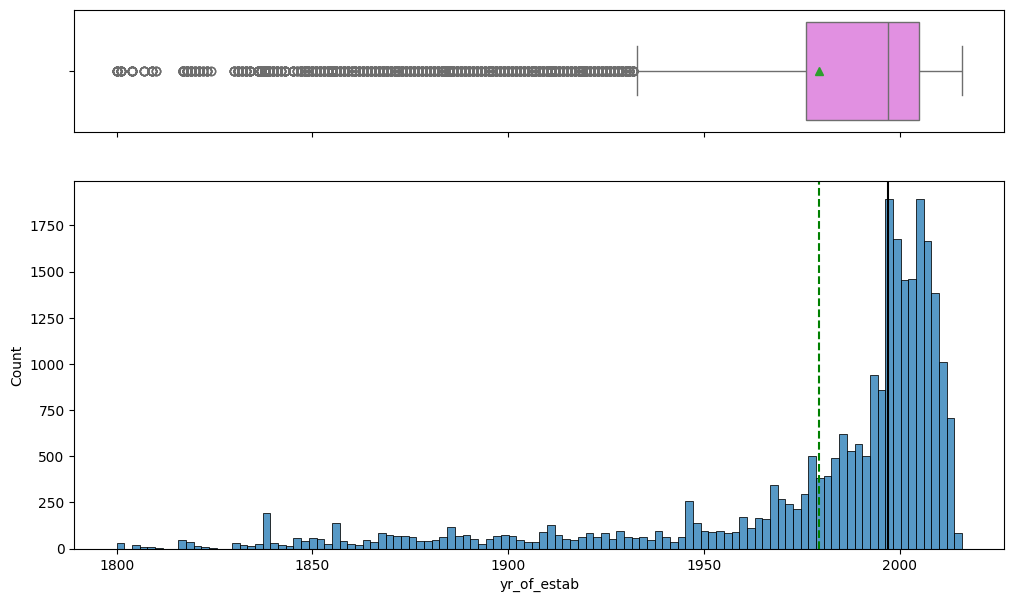

In [ ]:
# visualizing the distribution of the year in which the employer's company was established
histogram_boxplot(data, 'yr_of_estab')

- The distribution for the yr_of_estab is left skewed and highly concentrated around the median.
- There are outliers below the minimum value.
- To better analyze the distribution of yr_of_estab, we will categorize the values into multiple groups.

In [ ]:
# splitting the yr_of_estab column into multiple groups according to the age of the company

# defining bins
bins = (1800, 1996, 2006, 2011, 2016)
# defining labels
labels = ['Mature Stage','Growth Stage', 'Early Stage','Startup']

data['age_of_company'] = pd.cut(x = data['yr_of_estab'], bins = bins, labels = labels)
data.age_of_company.value_counts()

,count
age_of_company,
Mature Stage,12230
Growth Stage,8378
Early Stage,3569
Startup,1287


In [ ]:
# dropping yr_of_estab column
data.drop(columns=['yr_of_estab'], inplace=True)

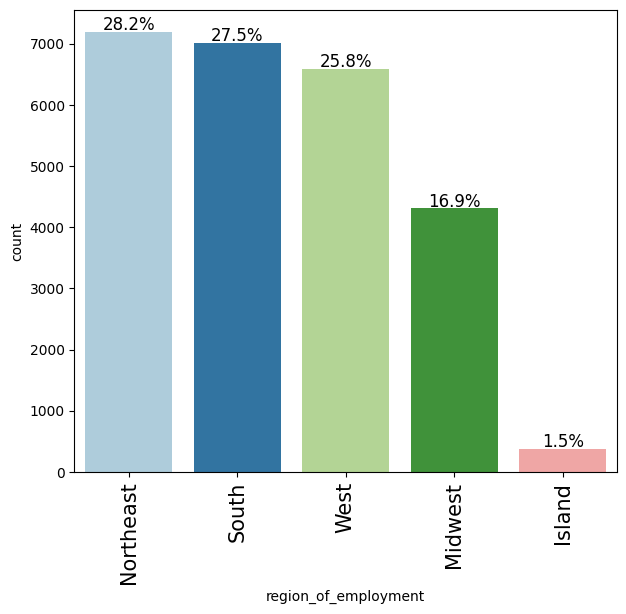

In [ ]:
# visualizing the distribution of the region of employment
labeled_barplot(data, 'region_of_employment',perc=True)

* Northeast has the highest percentage of the region of employment at 28.2%, followed by South at 27.5% and West at 25.8%.

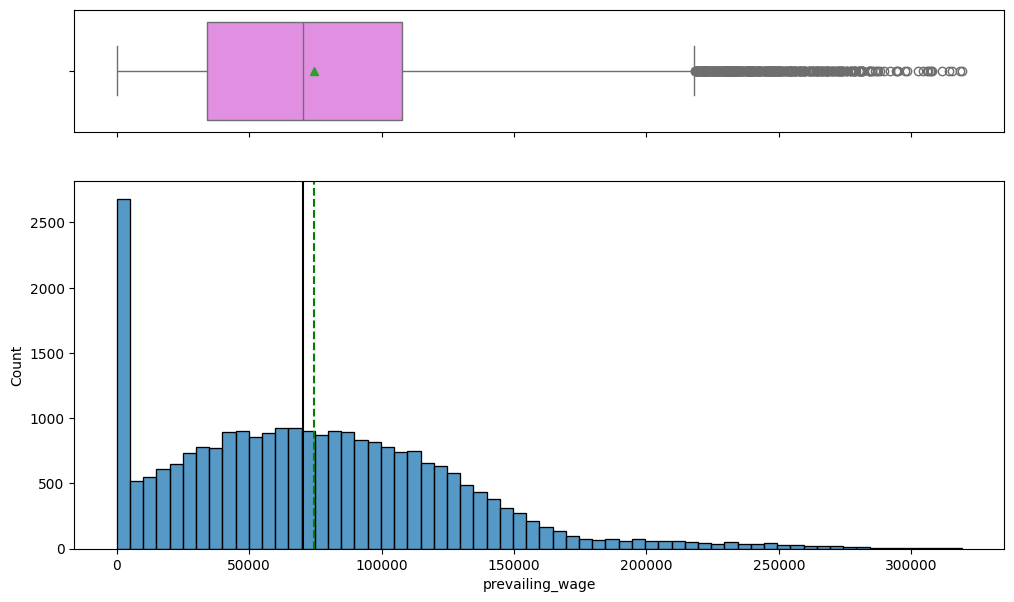

In [ ]:
# visualizing the distribution of prevailing wage
histogram_boxplot(data, 'prevailing_wage')

* It seems that the minimum has the highest concentration, which may be due to Hourly unit of wage for this value.
* Excluding the minimum value, the distribution for previaling wage is normally distributed and slightly right skewed.
* There are outliers above the maximum value.

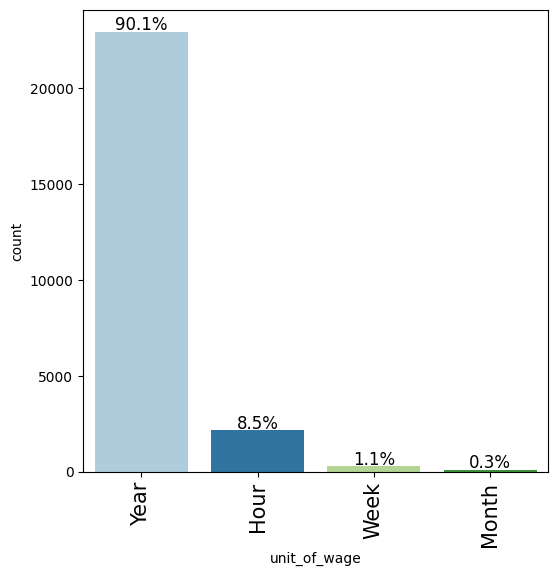

In [ ]:
# visualizing the distribution of unit of wage
labeled_barplot(data, 'unit_of_wage',perc=True)

* Yearly has the highest percentage of the unit of wage at 90.1%, followed by Hourly at 8.5%.

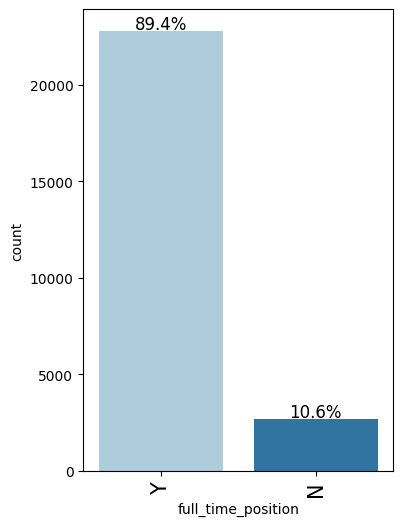

In [ ]:
# visualizing the distribution of whether the position is full time or not
labeled_barplot(data, 'full_time_position',perc=True)

* Almost 90% of the position is full time.

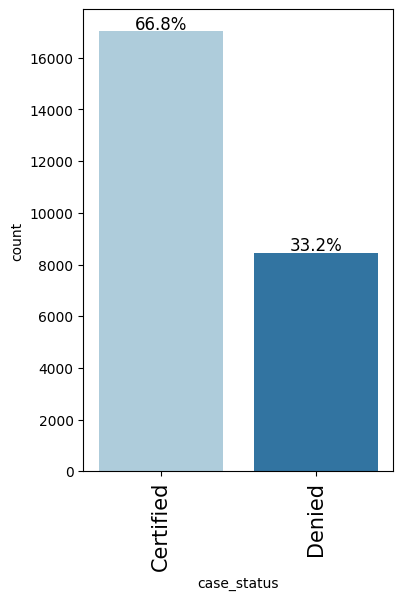

In [ ]:
# visualizing the distribution of case status
labeled_barplot(data, 'case_status',perc=True)

* Almost two-thirds of the cases are certified.

### Bivariate Analysis

#### continent vs. case_status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


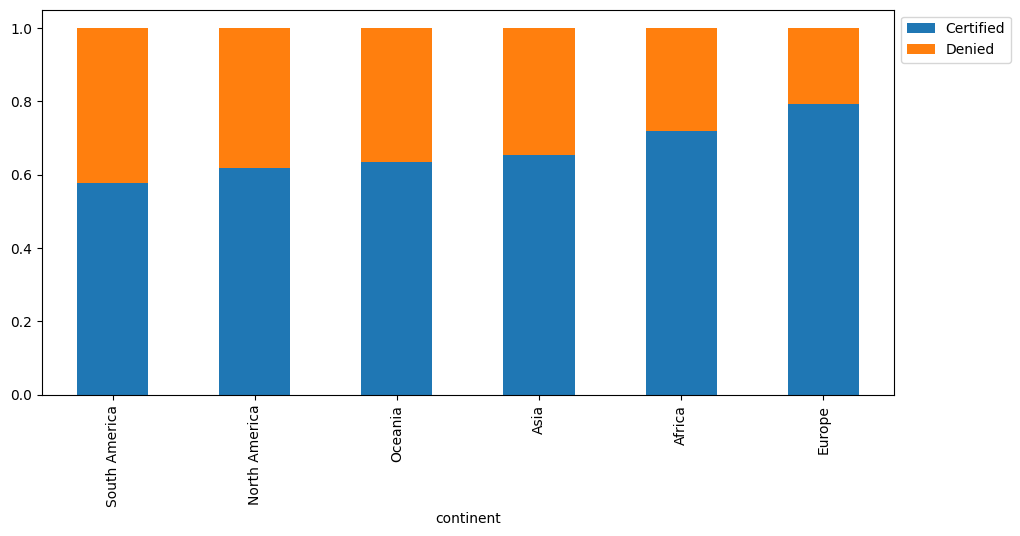

In [ ]:
stacked_barplot(data, 'continent', 'case_status')

* Europe has the highest rate of visa certification, followed by Africa and Asia, whereas South America has the lowest rate among the continents.

#### education_of_employee vs. case_status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


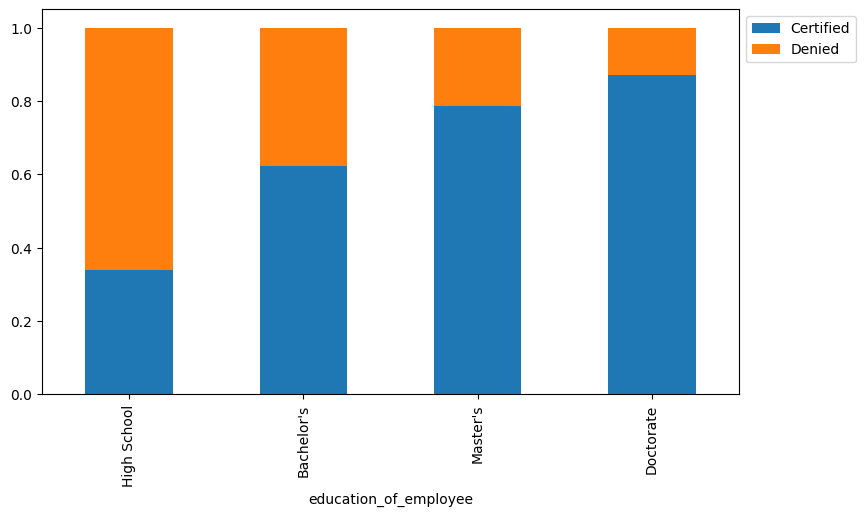

In [ ]:
stacked_barplot(data, 'education_of_employee', 'case_status')

* Predictably, Doctorate has the highest rate of visa certification, followed by Master's, whereas High School has the lowest rate of visa certification.
* Therefore, it is safe to say that education plays a significant role in visa certification.

#### has_job_experience vs. case_status

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


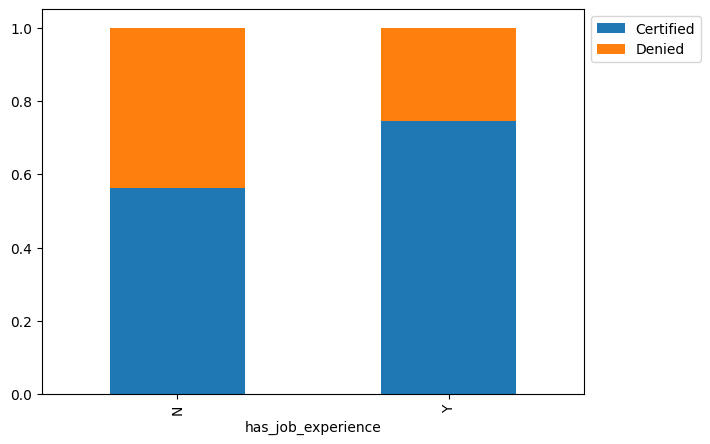

In [ ]:
stacked_barplot(data, 'has_job_experience', 'case_status')

* Over 70% of applicants with job experience are certified and less than 60% of applicants without job experience are certified.
* Work experience does appear to have an influence on visa status.

#### requires_job_training vs. case_status

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


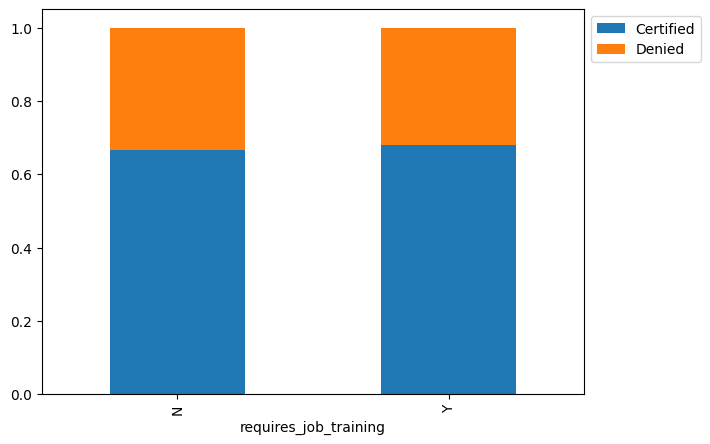

In [ ]:
stacked_barplot(data, 'requires_job_training', 'case_status')

* Whether an applicant requires job training or not does not make any difference in determining whether the visa application is certified or not.

#### co_size vs. case_status

case_status  Certified  Denied    All
co_size                              
All              17018    8462  25480
Large             7176    3516  10692
Small             6062    3152   9214
Medium            1919    1015   2934
Very large        1861     779   2640
------------------------------------------------------------------------------------------------------------------------


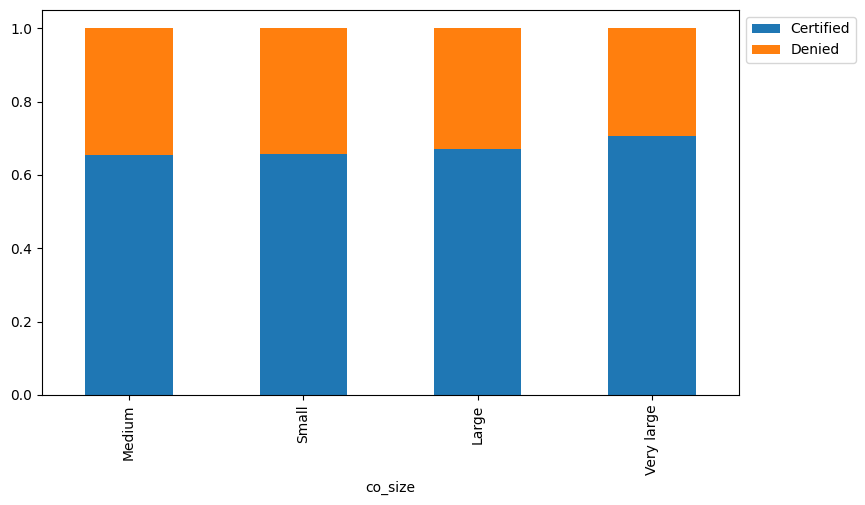

In [ ]:
stacked_barplot(data, 'co_size', 'case_status')

- Companies with different sizes have almost the same rate of visa certification, with very large companies slightly higher than the rest.

#### age_of_company vs. case_status

case_status     Certified  Denied    All
age_of_company                          
All                 17007    8457  25464
Mature Stage         8075    4155  12230
Growth Stage         5573    2805   8378
Early Stage          2484    1085   3569
Startup               875     412   1287
------------------------------------------------------------------------------------------------------------------------


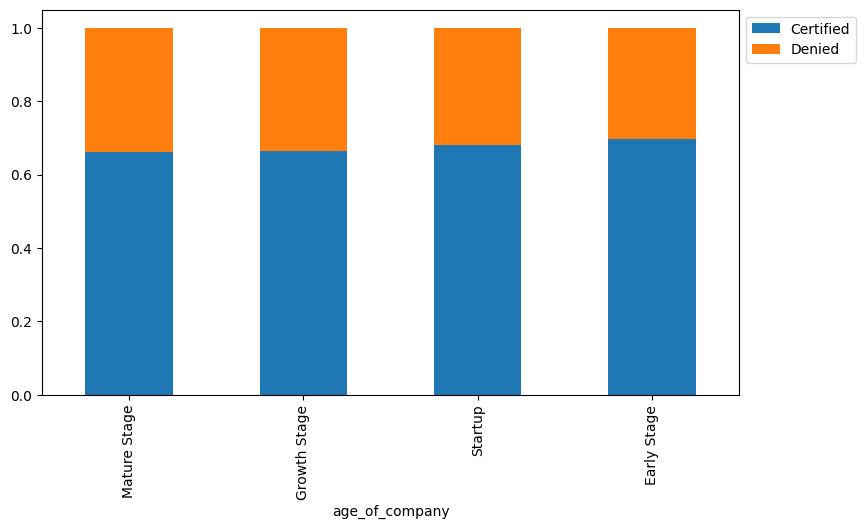

In [ ]:
stacked_barplot(data, 'age_of_company', 'case_status')

* Age of the company does not seem to make any difference in determining whether an applicant's visa is certified or not.

#### region_of_employment vs. case_status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


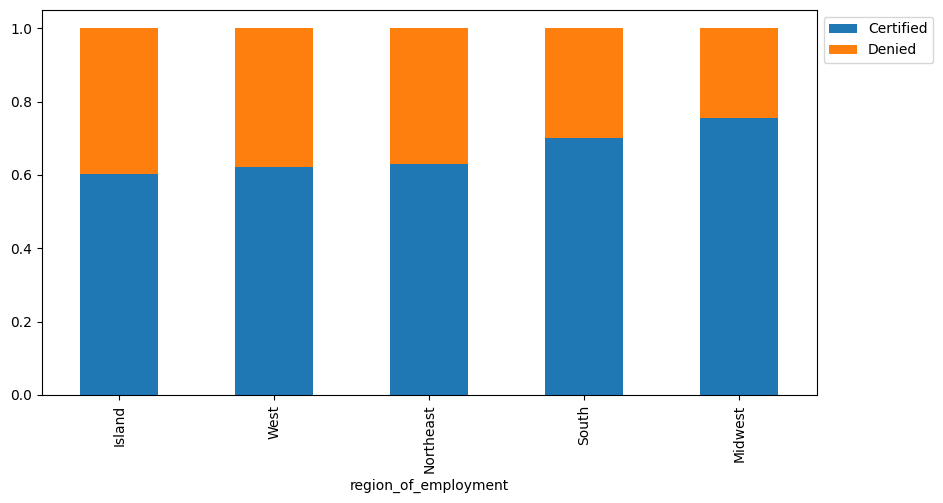

In [ ]:
stacked_barplot(data, 'region_of_employment', 'case_status')

* Midwest has the highest percentage of certification among the regions, followed by South.

#### prevailing_wage vs. case_status

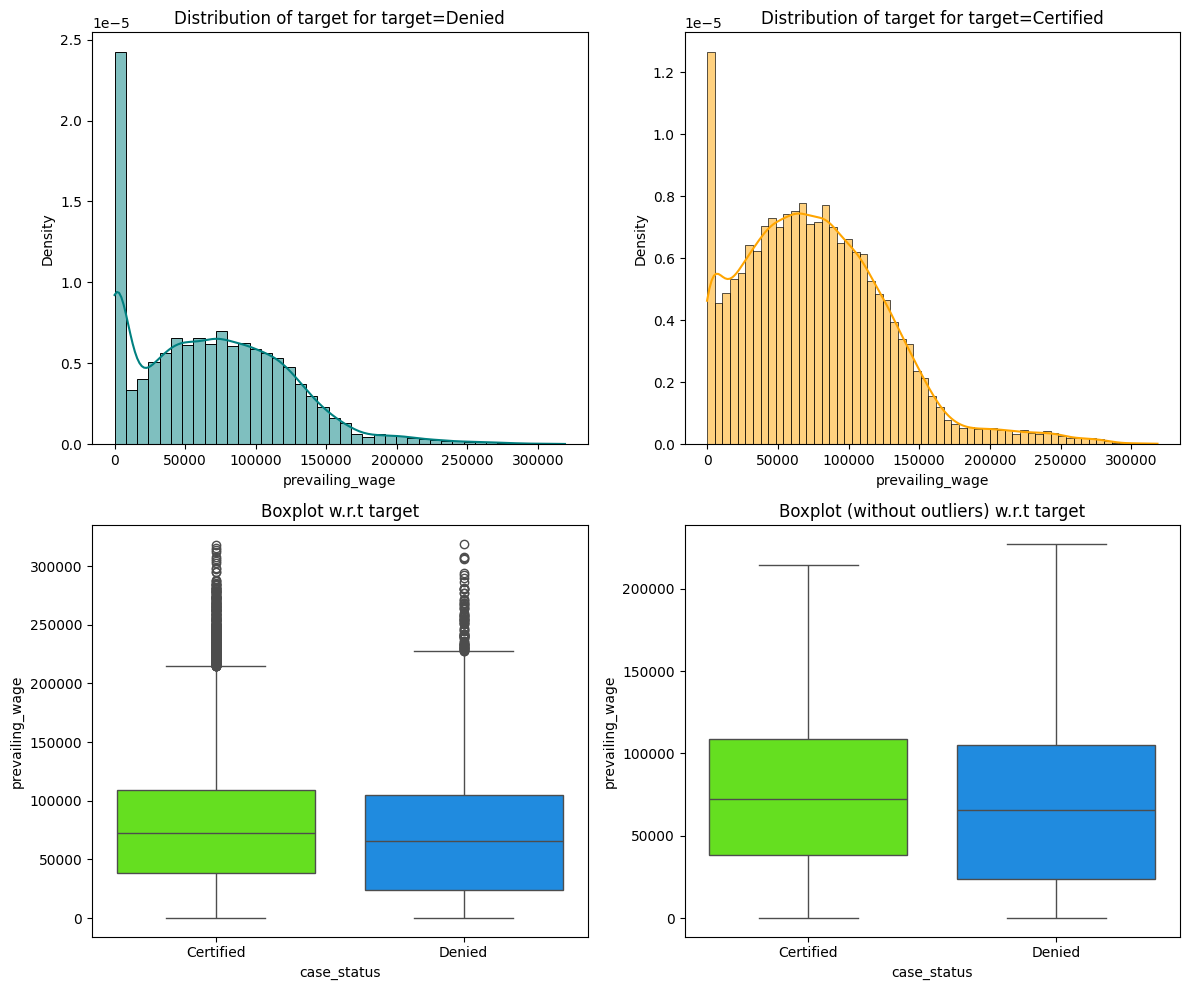

In [ ]:
# visualizing the relationship between prevailing_wage and case_status
distribution_plot_wrt_target(data, 'prevailing_wage', 'case_status')

* Certified group has higher prevailing wage than Denied group with or without outliers.

#### unit_of_wage vs. case_status

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


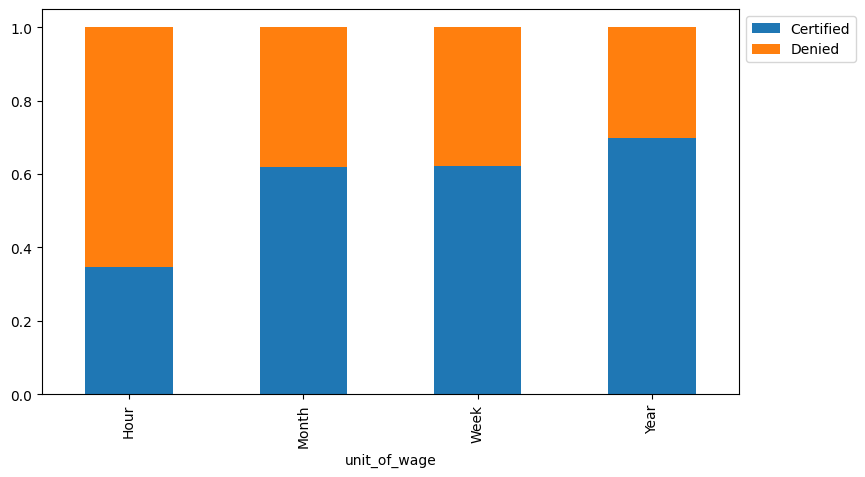

In [ ]:
# visualizing the distribution for unit of wage vs. case status
stacked_barplot(data, 'unit_of_wage', 'case_status')

* Yearly unit of wage has the highest percentage of visa certification, where as Hourly has the lowest percentage.

#### full_time_position vs. case_status

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


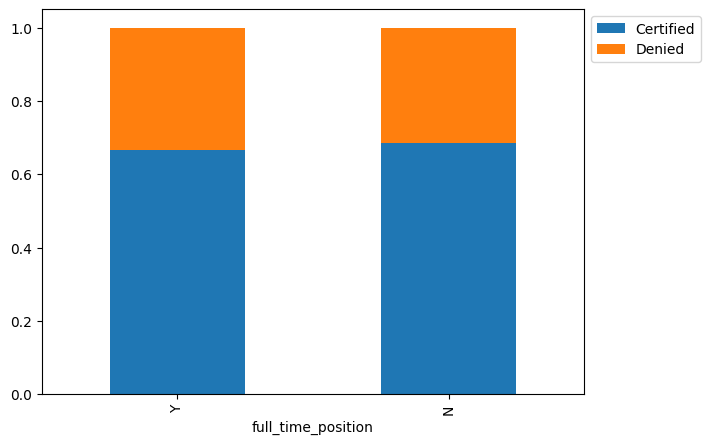

In [ ]:
# visualizing the distribution for full time position vs. case status
stacked_barplot(data, 'full_time_position', 'case_status')

* Full time position does not have any significant impact on determining whether visa application is certified or not.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,co_size,age_of_company
0,Asia,High School,N,N,West,592.2029,Hour,Y,Denied,Very large,Early Stage
1,Asia,Master's,Y,N,Northeast,83425.6500,Year,Y,Certified,Large,Growth Stage
2,Asia,Bachelor's,N,Y,West,122996.8600,Year,Y,Denied,Very large,Early Stage
3,Asia,Bachelor's,N,N,West,83434.0300,Year,Y,Denied,Small,Mature Stage
4,Africa,Master's,Y,N,South,149907.3900,Year,Y,Certified,Small,Growth Stage


In order to build and evaluate models we will convert non-numeric values into numerical values and create dummy variables for the categorical features.

In [ ]:
replaceStruct = {
                "education_of_employee":     {"High School": 1, "Bachelor's": 2 ,"Master's": 3 ,"Doctorate":4},
                "has_job_experience":     {"N": 1, "Y": 2 },
                "requires_job_training":     {"N": 1, "Y": 2 },
                "full_time_position":     {"N": 1, "Y": 2 },
                "case_status":     {"Denied": 0, "Certified": 1 }
                }
oneHotCols=["continent","region_of_employment","unit_of_wage", "co_size", "age_of_company"]

In [ ]:
data=data.replace(replaceStruct)
data=pd.get_dummies(data, columns=oneHotCols, dtype=int)
data.head(10)

,education_of_employee,has_job_experience,requires_job_training,prevailing_wage,full_time_position,case_status,continent_Africa,continent_Asia,continent_Europe,continent_North America,...,unit_of_wage_Week,unit_of_wage_Year,co_size_Small,co_size_Medium,co_size_Large,co_size_Very large,age_of_company_Mature Stage,age_of_company_Growth Stage,age_of_company_Early Stage,age_of_company_Startup
0,1,1,1,592.2029,2,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
1,3,2,1,83425.6500,2,1,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0
2,2,1,2,122996.8600,2,0,0,1,0,0,...,0,1,0,0,0,1,0,0,1,0
3,2,1,1,83434.0300,2,0,0,1,0,0,...,0,1,1,0,0,0,1,0,0,0
4,3,2,1,149907.3900,2,1,1,0,0,0,...,0,1,1,0,0,0,0,1,0,0
5,3,2,1,78252.1400,2,1,0,1,0,0,...,0,1,0,0,1,0,0,0,0,1
6,2,1,1,53635.3900,2,1,0,1,0,0,...,0,1,0,0,1,0,1,0,0,0
7,2,2,1,418.2298,2,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
8,2,1,1,74362.1900,2,1,0,1,0,0,...,0,1,0,0,1,0,0,0,0,1
9,4,2,1,67514.7600,2,1,0,0,1,0,...,0,1,0,0,1,0,1,0,0,0


Let's look at the distribution of target variable.

In [ ]:
data["case_status"].value_counts()

,count
case_status,
1,17018
0,8462


In [ ]:
data["case_status"].value_counts(normalize=True)

,proportion
case_status,
1,0.667896
0,0.332104


* The percentage of certified status is 66.8% of the total visa application.

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   education_of_employee           25480 non-null  category
 1   has_job_experience              25480 non-null  category
 2   requires_job_training           25480 non-null  category
 3   prevailing_wage                 25480 non-null  float64 
 4   full_time_position              25480 non-null  category
 5   case_status                     25480 non-null  category
 6   continent_Africa                25480 non-null  int64   
 7   continent_Asia                  25480 non-null  int64   
 8   continent_Europe                25480 non-null  int64   
 9   continent_North America         25480 non-null  int64   
 10  continent_Oceania               25480 non-null  int64   
 11  continent_South America         25480 non-null  int64   
 12  region_of_employme

* Since there were no missing values or outliers treated, we will pass on re-running EDA.
* After data manipulation and feature engineering, there are 23 int, 5 category and 1 float columns.

### Data Preparation for Modeling

#### Split the data into train and test sets

- When data (classification) exhibit a significant imbalance in the distribution of the target classes, it is good to use stratified sampling to ensure that relative class frequencies are approximately preserved in train and test sets.
- This is done by setting the `stratify` parameter to target variable in the train_test_split function.

In [ ]:
# Separating features and the target column
X = data.drop('case_status', axis=1)
y = data['case_status']

In [ ]:
# Splitting data into training and test set:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.3, random_state=1,stratify=y)
print(X_train.shape, X_test.shape)

(17836, 28) (7644, 28)


**Note**: The stratify argument maintains the original distribution of classes in the target variable while splitting the data into train and test sets.

- We have 17,836 observations in the train set and 7,644 observations in the test set.

In [ ]:
y.value_counts(1)

,proportion
case_status,
1,0.667896
0,0.332104


In [ ]:
y_test.value_counts(1)

,proportion
case_status,
1,0.667844
0,0.332156


## Model evaluation criterion

**The model can make wrong predictions as:**
1. Predicting an applicant's visa will be certified when it is denied.
2. Predicting an applicant's visa will be denied when it is certified.

**Which case is more important? **
1. If the model predicts an applicant's visa will be certified but it is denied, then employers may invest time and resources in onboarding an applicant whose visa is ultimately denied, which would compromise the trust in the employer's ability to manage the visa process if applicants receive misleading expectations. In addition, denied applicants who were misled by predictions may challenge the outcomes, causing an administrative burden to OFLC.
2. If the model predicts an applicant's visa will be denied when it is certified, then the company would lose access to qualified talent due to applicants withdrawing prematurely. Additionally, certified visa quotas may go unfilled, impacting the intended labor force or economic benefits negatively.

**Which metric to optimize?**
* We would want F1-Score to be maximized, the greater the F1-Score higher the chances of predicting both the classes correctly.

**Let's define a function to provide metric scores on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

**Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```

## Decision Tree - Model Building and Hyperparameter Tuning

### Decision Tree

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.653323  0.736337   0.742445  0.739378


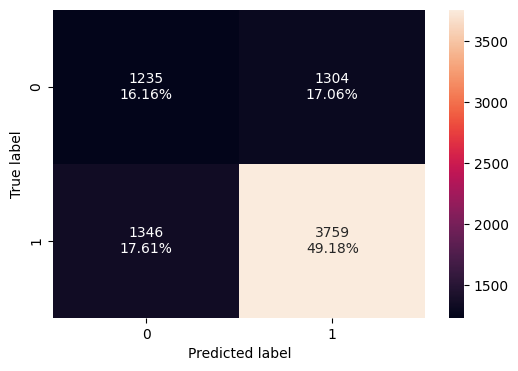

In [ ]:
#Fitting the model
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train,y_train)

#Calculating different metrics
d_tree_model_train_perf=model_performance_classification_sklearn(d_tree,X_train,y_train)
print("Training performance:\n",d_tree_model_train_perf)
d_tree_model_test_perf=model_performance_classification_sklearn(d_tree,X_test,y_test)
print("Testing performance:\n",d_tree_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(d_tree,X_test,y_test)

* The decision tree is overfitting the training data.
* Let's try hyperparameter tuning and see if the model performance improves.

### Hyperparameter Tuning

In [ ]:
#Choose the type of classifier.
#The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y))
dtree_estimator = DecisionTreeClassifier(class_weight="balanced",random_state=1)

# Grid of parameters to choose from
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, param_grid, scoring=scorer,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4, max_leaf_nodes=15,
                       min_impurity_decrease=0.001, random_state=1)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.716641  0.779569   0.792744  0.786101
Testing performance:
    Accuracy   Recall  Precision        F1
0  0.715594  0.78237   0.789796  0.786066


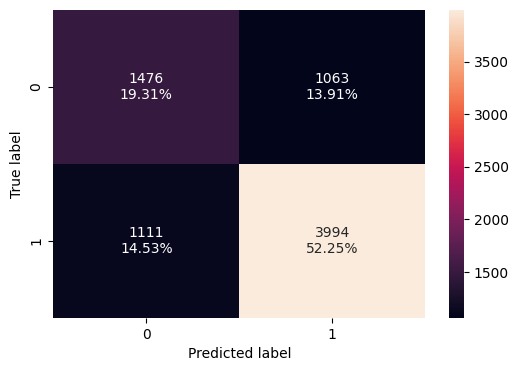

In [ ]:
#Calculating different metrics
dtree_estimator_model_train_perf=model_performance_classification_sklearn(dtree_estimator,X_train,y_train)
print("Training performance:\n",dtree_estimator_model_train_perf)
dtree_estimator_model_test_perf=model_performance_classification_sklearn(dtree_estimator,X_test,y_test)
print("Testing performance:\n",dtree_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(dtree_estimator,X_test,y_test)

* The overfitting has reduced and the test f1-score has also increased.
* Let's try some other models.

## Building bagging and boosting models

### Bagging - Model Building and Hyperparameter Tuning

#### Random Forest Classifier

Training performance:
    Accuracy    Recall  Precision        F1
0  0.999888  0.999916   0.999916  0.999916
Testing performance:
    Accuracy    Recall  Precision       F1
0  0.683935  0.778257   0.755754  0.76684


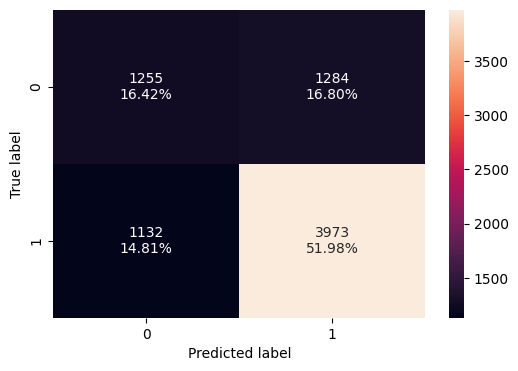

In [ ]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

#Calculating different metrics
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator,X_test,y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_estimator,X_test,y_test)

* Random forest is overfitting the training data.
* Let's try hyperparameter tuning and see if the model performance improves.

#### Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
#The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y))
rf_tuned = RandomForestClassifier(class_weight="balanced",random_state=1,oob_score=True,bootstrap=True)

param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, param_grid, scoring=scorer, cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_samples=0.4,
                       n_estimators=110, oob_score=True, random_state=1)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.896726  0.958281   0.894601  0.925347
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.712716  0.835651    0.75867  0.795302


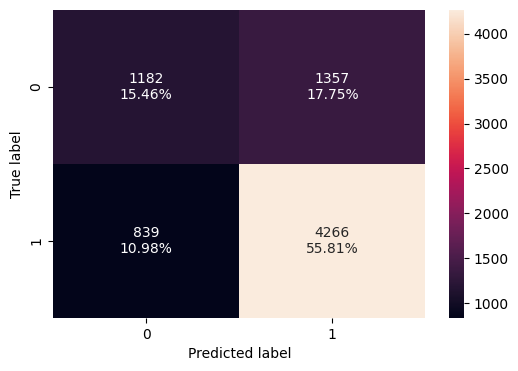

In [ ]:
#Calculating different metrics
rf_tuned_model_train_perf=model_performance_classification_sklearn(rf_tuned,X_train,y_train)
print("Training performance:\n",rf_tuned_model_train_perf)
rf_tuned_model_test_perf=model_performance_classification_sklearn(rf_tuned,X_test,y_test)
print("Testing performance:\n",rf_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_tuned,X_test,y_test)

* The model performance has improved slightly but it is still overfitting the training data.
* The test recall and test f1-score have increased.

#### Bagging Classifier

   Accuracy    Recall  Precision        F1
0  0.980321  0.981197   0.989252  0.985208
   Accuracy    Recall  Precision        F1
0  0.683281  0.755926   0.766587  0.761219


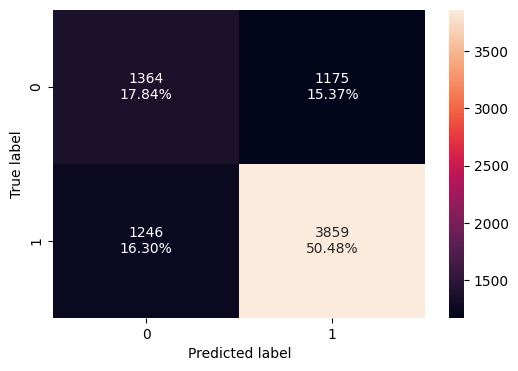

In [ ]:
#Fitting the model
bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train,y_train)

#Calculating different metrics
bagging_classifier_model_train_perf=model_performance_classification_sklearn(bagging_classifier,X_train,y_train)
print(bagging_classifier_model_train_perf)
bagging_classifier_model_test_perf=model_performance_classification_sklearn(bagging_classifier,X_test,y_test)
print(bagging_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(bagging_classifier,X_test,y_test)

* Bagging classifier is overfitting the training data.
* Let's try hyperparameter tuning and see if the model performance improves.

#### Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, param_grid, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.9, n_estimators=50,
                  random_state=1)

   Accuracy    Recall  Precision        F1
0  0.966641  0.996978    0.95505  0.975564
   Accuracy    Recall  Precision        F1
0  0.720434  0.874045   0.749161  0.806799


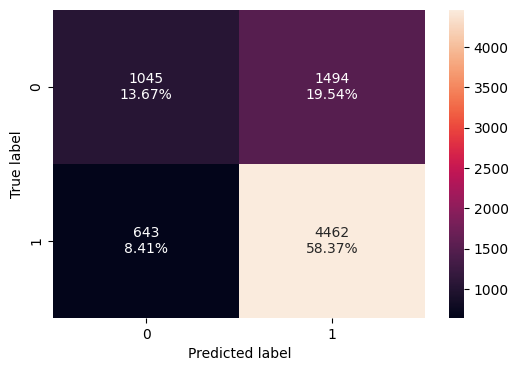

In [ ]:
bagging_estimator_tuned_model_train_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_train,y_train)
print(bagging_estimator_tuned_model_train_perf)
bagging_estimator_tuned_model_test_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_test,y_test)
print(bagging_estimator_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(bagging_estimator_tuned,X_test,y_test)

* The model performance has improved slightly but it is still overfitting the training data.
* The test recall and test f1-score have increased.

### Boosting - Model Building and Hyperparameter Tuning

#### AdaBoost Classifier

   Accuracy    Recall  Precision        F1
0  0.736937  0.887686   0.759207  0.818435
   Accuracy    Recall  Precision        F1
0  0.734694  0.886974   0.757317  0.817034


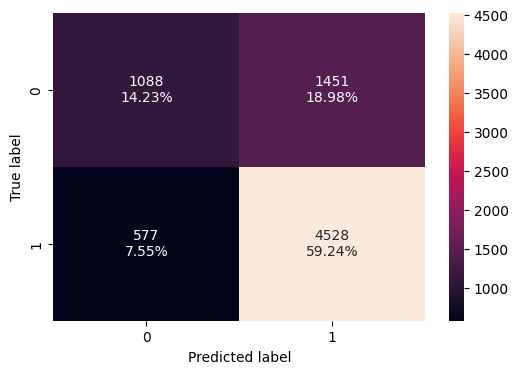

In [ ]:
#Fitting the model
ab_classifier = AdaBoostClassifier(random_state=1)
ab_classifier.fit(X_train,y_train)

#Calculating different metrics
ab_classifier_model_train_perf=model_performance_classification_sklearn(ab_classifier,X_train,y_train)
print(ab_classifier_model_train_perf)
ab_classifier_model_test_perf=model_performance_classification_sklearn(ab_classifier,X_test,y_test)
print(ab_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(ab_classifier,X_test,y_test)

* Adaboost is not overfitting the training data and the test f1-score has increased.
* Let's try hyperparameter tuning and see if the model performance improves.

#### Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
# Type of scoring used to compare parameter  combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned, param_grid, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         random_state=1),
                   learning_rate=0.1, n_estimators=75, random_state=1)

   Accuracy    Recall  Precision        F1
0  0.756392  0.884412   0.780213  0.829051
   Accuracy   Recall  Precision        F1
0   0.74529  0.87953   0.771213  0.821818


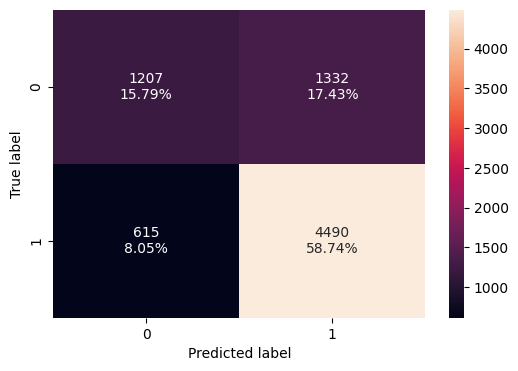

In [ ]:
#Calculating different metrics
abc_tuned_model_train_perf=model_performance_classification_sklearn(abc_tuned,X_train,y_train)
print(abc_tuned_model_train_perf)
abc_tuned_model_test_perf=model_performance_classification_sklearn(abc_tuned,X_test,y_test)
print(abc_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(abc_tuned,X_test,y_test)

* The model performance has increased slightly.

#### Gradient Boosting Classifier

Training performance:
    Accuracy   Recall  Precision        F1
0  0.756055  0.87862   0.782755  0.827922
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.74686  0.875612   0.774697  0.822069


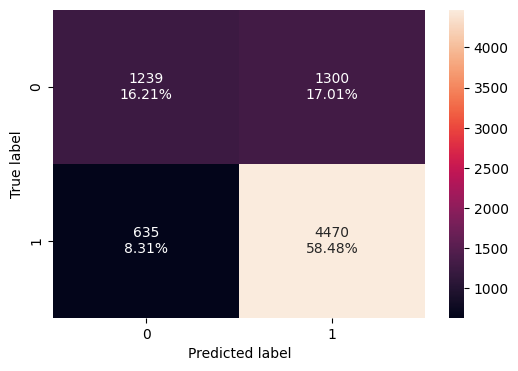

In [ ]:
#Fitting the model
gb_classifier = GradientBoostingClassifier(random_state=1)
gb_classifier.fit(X_train,y_train)

#Calculating different metrics
gb_classifier_model_train_perf=model_performance_classification_sklearn(gb_classifier,X_train,y_train)
print("Training performance:\n",gb_classifier_model_train_perf)
gb_classifier_model_test_perf=model_performance_classification_sklearn(gb_classifier,X_test,y_test)
print("Testing performance:\n",gb_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(gb_classifier,X_test,y_test)

* Gradient Boosting Classifier is not overfitting the training data and the test f1-score has increased slightly.
* Let's try hyperparameter tuning and see if the model performance improves.

#### Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, param_grid, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, random_state=1, subsample=0.9)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.755607  0.879711    0.78174  0.827837
Testing performance:
    Accuracy    Recall  Precision       F1
0   0.74686  0.874241   0.775365  0.82184


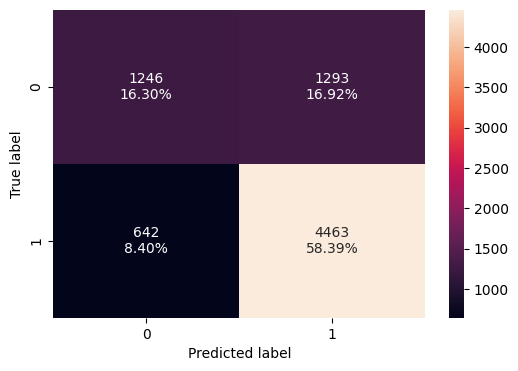

In [ ]:
#Calculating different metrics
gbc_tuned_model_train_perf=model_performance_classification_sklearn(gbc_tuned,X_train,y_train)
print("Training performance:\n",gbc_tuned_model_train_perf)
gbc_tuned_model_test_perf=model_performance_classification_sklearn(gbc_tuned,X_test,y_test)
print("Testing performance:\n",gbc_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(gbc_tuned,X_test,y_test)

* There is not much difference in the model performance after hyperparameter tuning.

#### XGBoost Classifier

In [ ]:
# Convert specific columns to numeric dtype
for col in ['education_of_employee', 'has_job_experience', 'requires_job_training', 'full_time_position']:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

Training performance:
    Accuracy    Recall  Precision        F1
0   0.81784  0.914631   0.829982  0.870253
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.729069  0.853085   0.767266  0.807903


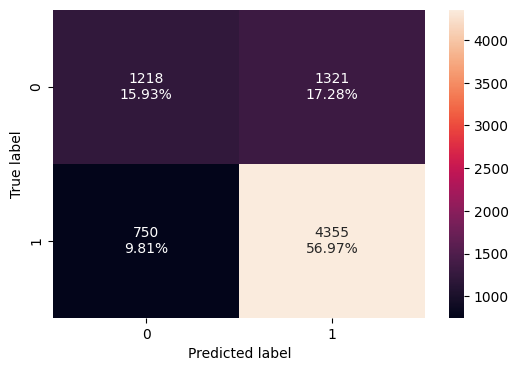

In [ ]:
#Fitting the model
xgb_classifier = XGBClassifier(random_state=1, eval_metric='logloss')
xgb_classifier.fit(X_train,y_train)

#Calculating different metrics
xgb_classifier_model_train_perf=model_performance_classification_sklearn(xgb_classifier,X_train,y_train)
print("Training performance:\n",xgb_classifier_model_train_perf)
xgb_classifier_model_test_perf=model_performance_classification_sklearn(xgb_classifier,X_test,y_test)
print("Testing performance:\n",xgb_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_classifier,X_test,y_test)

* xgboost classifier is overfitting the training data.
* Let's try hyperparameter tuning and see if the model performance improves.

#### Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric='logloss')

# Grid of parameters to choose from
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, param_grid,scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

Training performance:
    Accuracy    Recall  Precision       F1
0  0.760092  0.882649   0.784936  0.83093
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.745814  0.873066   0.774861  0.821037


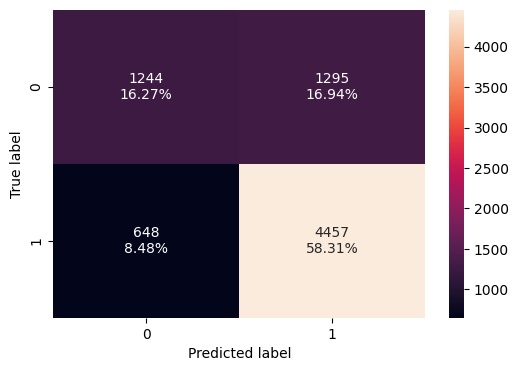

In [ ]:
#Calculating different metrics
xgb_tuned_model_train_perf=model_performance_classification_sklearn(xgb_tuned,X_train,y_train)
print("Training performance:\n",xgb_tuned_model_train_perf)
xgb_tuned_model_test_perf=model_performance_classification_sklearn(xgb_tuned,X_test,y_test)
print("Testing performance:\n",xgb_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned,X_test,y_test)

* The model is not overfitting the training data and the model performance has improved slightly.

### Stacking Model

In [ ]:
estimators = [('Random Forest',rf_tuned), ('Gradient Boosting',gbc_tuned), ('Decision Tree',dtree_estimator)]

final_estimator = xgb_tuned

stacking_classifier= StackingClassifier(estimators=estimators,final_estimator=final_estimator)

stacking_classifier.fit(X_train,y_train)

StackingClassifier(estimators=[('Random Forest',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_samples=0.4,
                                                       n_estimators=110,
                                                       oob_score=True,
                                                       random_state=1)),
                               ('Gradient Boosting',
                                GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                                                           max_features=0.7,
                                                           random_state=1,
                                                           subsample=0.9)),
                               ('Decision Tree',
                                DecisionTreeClassifier(class_weight='bal...
                                                 feature_types=None, gamma=3,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.05,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=50, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=1, ...))

Training performance:
    Accuracy    Recall  Precision        F1
0  0.759924  0.887266   0.782441  0.831563
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.746337  0.879726    0.77218  0.822452


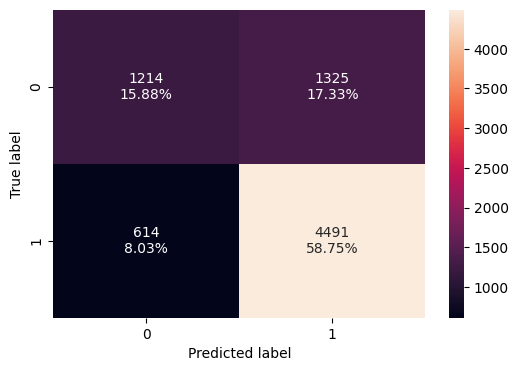

In [ ]:
#Calculating different metrics
stacking_classifier_model_train_perf=model_performance_classification_sklearn(stacking_classifier,X_train,y_train)
print("Training performance:\n",stacking_classifier_model_train_perf)
stacking_classifier_model_test_perf=model_performance_classification_sklearn(stacking_classifier,X_test,y_test)
print("Testing performance:\n",stacking_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(stacking_classifier,X_test,y_test)

* The stacking classifier is not overfitting the training data and is giving a slightly better performance than XGBoost.

##  Will tuning the hyperparameters improve the model performance?

* See the above for the details on the model performance of different models before and after hyperparameter tuning.
* With the exception of Gradient Boosting Classifier, all the models' performance improved after tuning hyperparameters.

## Model Performance Comparison and Conclusions

### Comparing all models

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [d_tree_model_train_perf.T,dtree_estimator_model_train_perf.T,rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
     bagging_classifier_model_train_perf.T,bagging_estimator_tuned_model_train_perf.T,ab_classifier_model_train_perf.T,
     abc_tuned_model_train_perf.T,gb_classifier_model_train_perf.T,gbc_tuned_model_train_perf.T,xgb_classifier_model_train_perf.T,
    xgb_tuned_model_train_perf.T,stacking_classifier_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned",
    "Adaboost Classifier",
    "Adabosst Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Estimator,Random Forest Estimator,Random Forest Tuned,Bagging Classifier,Bagging Estimator Tuned,Adaboost Classifier,Adabosst Classifier Tuned,Gradient Boost Classifier,Gradient Boost Classifier Tuned,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,1.0,0.716641,0.999888,0.896726,0.980321,0.966641,0.736937,0.756392,0.756055,0.755607,0.817840,0.760092,0.759924
Recall,1.0,0.779569,0.999916,0.958281,0.981197,0.996978,0.887686,0.884412,0.878620,0.879711,0.914631,0.882649,0.887266
Precision,1.0,0.792744,0.999916,0.894601,0.989252,0.955050,0.759207,0.780213,0.782755,0.781740,0.829982,0.784936,0.782441
F1,1.0,0.786101,0.999916,0.925347,0.985208,0.975564,0.818435,0.829051,0.827922,0.827837,0.870253,0.830930,0.831563


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [d_tree_model_test_perf.T,dtree_estimator_model_test_perf.T,rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
     bagging_classifier_model_test_perf.T,bagging_estimator_tuned_model_test_perf.T,ab_classifier_model_test_perf.T,
     abc_tuned_model_test_perf.T,gb_classifier_model_test_perf.T,gbc_tuned_model_test_perf.T,xgb_classifier_model_test_perf.T,
    xgb_tuned_model_test_perf.T,stacking_classifier_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned",
    "Adaboost Classifier",
    "Adabosst Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Estimator,Random Forest Estimator,Random Forest Tuned,Bagging Classifier,Bagging Estimator Tuned,Adaboost Classifier,Adabosst Classifier Tuned,Gradient Boost Classifier,Gradient Boost Classifier Tuned,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,0.653323,0.715594,0.683935,0.712716,0.683281,0.720434,0.734694,0.745290,0.746860,0.746860,0.729069,0.745814,0.746337
Recall,0.736337,0.782370,0.778257,0.835651,0.755926,0.874045,0.886974,0.879530,0.875612,0.874241,0.853085,0.873066,0.879726
Precision,0.742445,0.789796,0.755754,0.758670,0.766587,0.749161,0.757317,0.771213,0.774697,0.775365,0.767266,0.774861,0.772180
F1,0.739378,0.786066,0.766840,0.795302,0.761219,0.806799,0.817034,0.821818,0.822069,0.821840,0.807903,0.821037,0.822452


* The stacking classifier is giving the highest f1-score on the test data.
* The gradient boosting classifier without hyperparameter tuning has given the second-highest test f1-score and is giving a generalized performance.

### Feature importance of Gradient Boosting Classifier

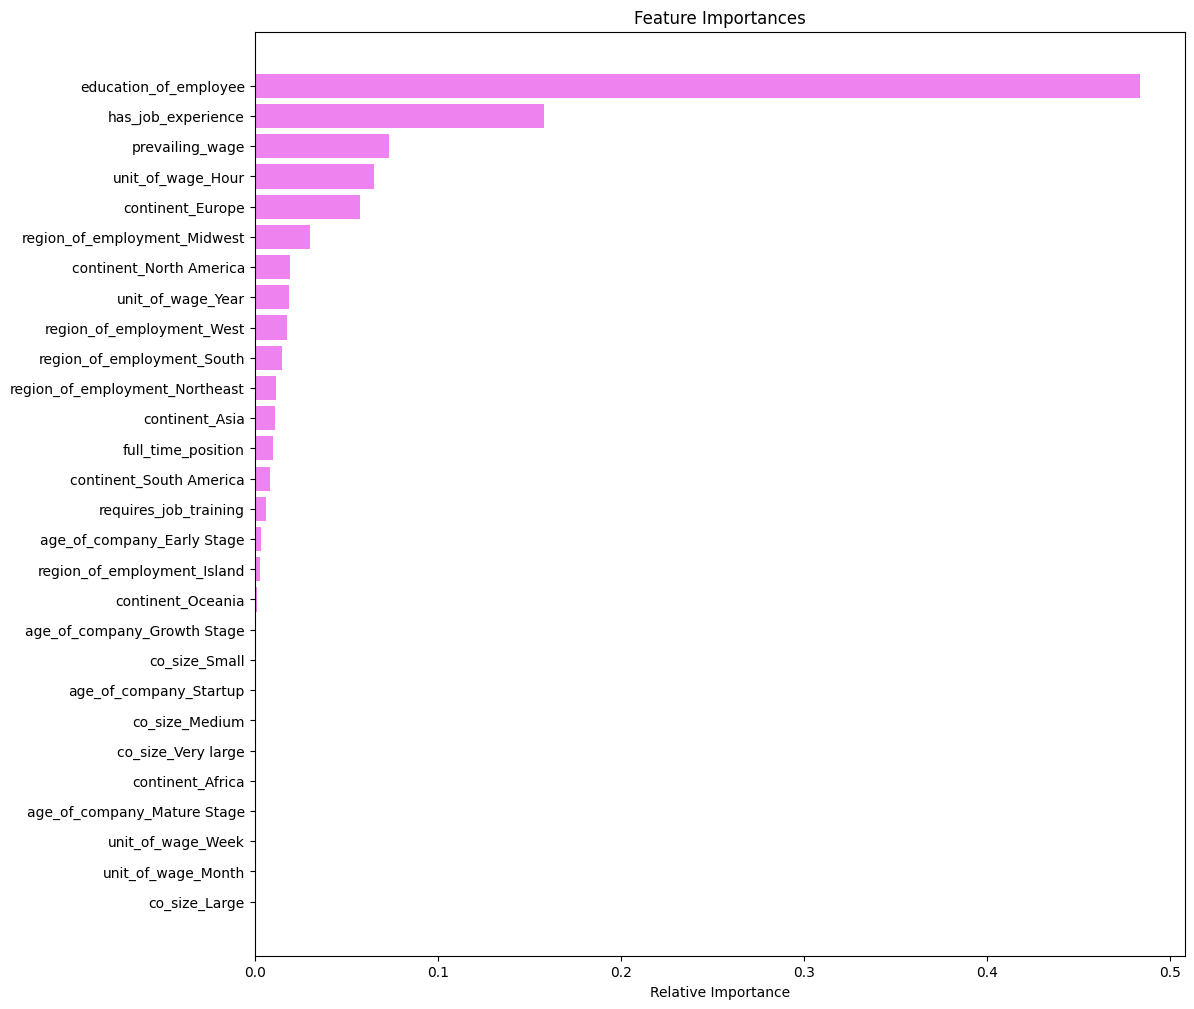

In [ ]:
feature_names = X_train.columns
importances = gb_classifier.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

* Education of employee is the most important feature in determining whether an applicant's visa is certified or denied, followed by job experience.

## Actionable Insights and Recommendations

- Based on our analysis, applicants with the following features have a high chance of getting their visas certified:
    - Education of employee.
    - Job experience

1. The company/OFLC should deploy the gradient boosting classifier model to prioritize applications with a higher likelihood of approval for faster processing, which will reduce the burden of human reviewers.
2. The company/OFLC should develop an applicant pre-screening procedure to screen out candidates without relevant educational qualifications and job experience.
3. The current classifier model can be improved/refined by collecting and testing more samples with additional features such as type of jobs, area of study/specialization, competitiveness of educational institutions, standardized test scores, if any, of the applicants, etc.